In [94]:
import jax.numpy as jnp
import jax
jax.config.update('jax_enable_x64',True)
from keql_tools.Kernels import get_gaussianRBF
from keql_tools.KernelTools import get_kernel_block_ops,vectorize_kfunc
from keql_tools.Optimizers import CholeskyLM,LMParams,SVD_LM
import matplotlib.pyplot as plt

from jax.random import PRNGKey as pkey
from tqdm.auto import tqdm

In [31]:
interior_points = jax.random.uniform(pkey(130),(500,2))

num_per_piece = 30
grid = jnp.linspace(0,1,2+num_per_piece)[1:-1]
bdy_points = jnp.vstack(
    [
        jnp.hstack(
            [grid[:,None],jnp.ones((num_per_piece,1))]
        ),
        jnp.hstack(
            [grid[:,None],jnp.zeros((num_per_piece,1))]
        ),
        jnp.hstack(
            [jnp.ones((num_per_piece,1)),grid[:,None]]
        ),
        jnp.hstack(
            [jnp.zeros((num_per_piece,1)),grid[:,None]]
        ),]
)
num_bdy = len(bdy_points)

In [145]:
def u_sol(x1, x2):
    return jnp.sin(jnp.pi * x1) * jnp.sin(jnp.pi * x2) + \
           4 * jnp.sin(4 * jnp.pi * x1) * jnp.sin(4 * jnp.pi * x2)

# Forcing term f(x) computed as f = -Δu + u^3.
def f_func(x1, x2):
    # For v(x) = sin(pi*x1)*sin(pi*x2)
    v = jnp.sin(jnp.pi * x1) * jnp.sin(jnp.pi * x2)
    lap_v = -2 * jnp.pi**2 * v
    
    # For w(x) = 4*sin(4*pi*x1)*sin(4*pi*x2)
    w = 4 * jnp.sin(4 * jnp.pi * x1) * jnp.sin(4 * jnp.pi * x2)
    lap_w = -128 * jnp.pi**2 * jnp.sin(4 * jnp.pi * x1) * jnp.sin(4 * jnp.pi * x2)
    
    lap_u = lap_v + lap_w
    return -lap_u + 5*u_sol(x1, x2)**3


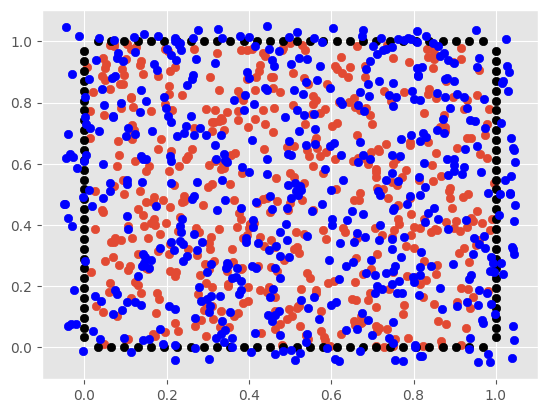

In [146]:
k = get_gaussianRBF(0.1)
def laplacian(k,index):
    def lap_k(x,y):
        return jnp.linalg.trace(jax.hessian(k,index)(x,y))
    return lap_k

num_basis = 500
basis_points = jax.random.uniform(pkey(8),(num_basis,2),minval = -0.05,maxval = 1.05)

def tau(u):
    return 5*u**3


@jax.jit
def pde_residual(alpha):
    Kphi = vectorize_kfunc(laplacian(k,0))(interior_points,basis_points)
    lap_u = Kphi@alpha
    u = vectorize_kfunc(k)(interior_points,basis_points)@alpha
    Fu = -lap_u + tau(u)
    residual = f_func(interior_points[:,0],interior_points[:,1]) - Fu
    return residual

@jax.jit
def bdy_residual(alpha):
    return vectorize_kfunc(k)(bdy_points,basis_points)@alpha

bdy_weight = 2.

@jax.jit
def full_residual(alpha):
    pde_res = pde_residual(alpha)
    bdy_res = bdy_residual(alpha)
    return jnp.hstack([pde_res,bdy_res])

K = vectorize_kfunc(k)(basis_points,basis_points)
damping_mat = K + 1e-5 * jnp.eye(num_basis)
jacres = jax.jit(jax.jacobian(full_residual))

class pde_model():
    def __init__(self):
        pass

    def F(self,alpha):
        return full_residual(alpha)
    
    def jac(self,alpha):
        return jacres(alpha)
    
    def damping_matrix(self,alpha):
        return damping_mat

plt.scatter(interior_points[:,0],interior_points[:,1])
plt.scatter(bdy_points[:,0],bdy_points[:,1],c='black')
plt.scatter(basis_points[:,0],basis_points[:,1],c='blue')

In [147]:
I = jnp.eye(num_basis)
mu = 1e-7
rho = 1e-8

In [148]:
settings = LMParams(max_iter = 10000,print_every=1000)
model = pde_model()
alpha = jnp.zeros(num_basis)

alpha,conv_history = CholeskyLM(
    alpha,
    model,
    1e-14,
    optParams = settings
)

  0%|          | 0/10000 [00:00<?, ?it/s]

Iteration 0, loss = 7.133e+07, gradnorm = 3.174e+07, alpha = 3.0, improvement_ratio = 0.5085
Iteration 1, loss = 3.17e+06, gradnorm = 1.354e+08, alpha = 2.5, improvement_ratio = 0.9556
Iteration 2, loss = 6.77e+04, gradnorm = 1.66e+07, alpha = 2.083, improvement_ratio = 0.9787
Iteration 3, loss = 120.9, gradnorm = 1.769e+06, alpha = 1.736, improvement_ratio = 0.9985
Iteration 4, loss = 9.652, gradnorm = 6.39e+04, alpha = 1.447, improvement_ratio = 0.9973
Iteration 5, loss = 6.417, gradnorm = 1.569e+03, alpha = 1.206, improvement_ratio = 0.973
Iteration 1000, loss = 0.004513, gradnorm = 8.256e-06, alpha = 0.0003068, improvement_ratio = 1.0
Iteration 2000, loss = 0.003692, gradnorm = 1.035e-05, alpha = 0.0002347, improvement_ratio = 1.0
Iteration 3000, loss = 0.00329, gradnorm = 1.088e-05, alpha = 0.0002694, improvement_ratio = 1.0
Iteration 4000, loss = 0.003021, gradnorm = 1.47e-05, alpha = 0.0003092, improvement_ratio = 1.0
Iteration 5000, loss = 0.002814, gradnorm = 9.92e-06, alpha =

In [149]:
# alpha = jnp.zeros(num_basis)
# loss_vals = []
# for i in tqdm(range(200)):
#     F = full_residual(alpha)
#     loss_vals.append(jnp.sum(F**2))
#     J = jacres(alpha)
#     step = jnp.linalg.solve(J.T@J + mu *K + rho * I,J.T@F)
#     alpha = alpha - step
    
# plt.plot(loss_vals)
# plt.yscale('log')


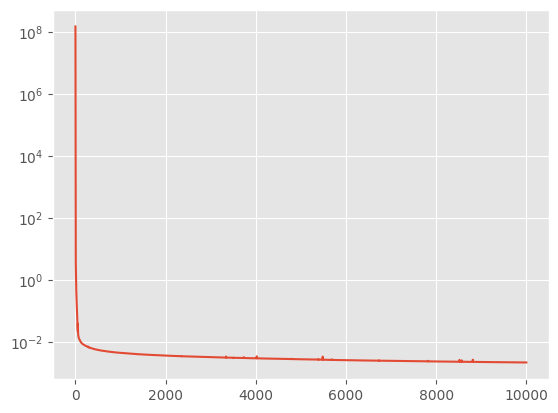

In [150]:
plt.plot(conv_history.loss_vals)
plt.yscale('log')

In [151]:
grid = jnp.linspace(0,1,50)
gx,gy = jnp.meshgrid(grid,grid)
grid = jnp.vstack([gx.flatten(),gy.flatten()]).T

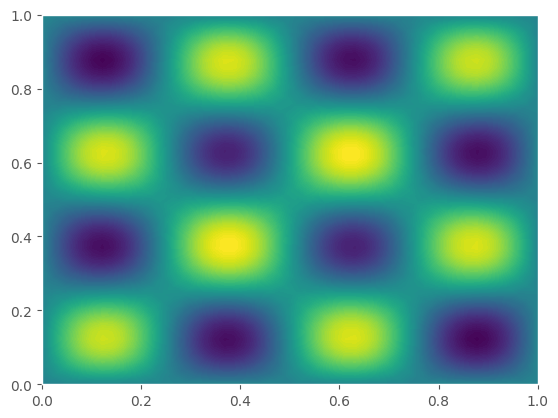

In [152]:
u_grid = vectorize_kfunc(k)(grid,basis_points)@alpha
u_true = u_sol(grid[:,0],grid[:,1])
plt.tricontourf(grid[:,0],grid[:,1],u_grid,100)

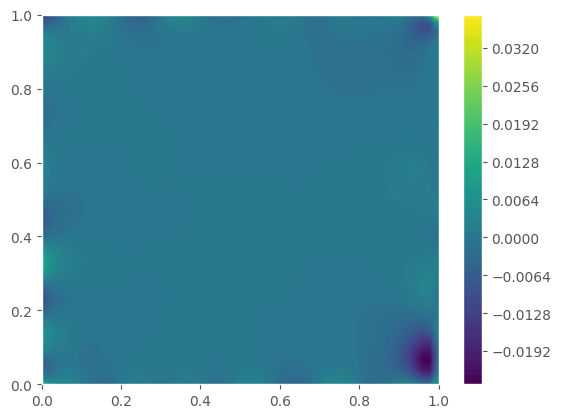

In [153]:
u_true = u_sol(grid[:,0],grid[:,1])
plt.tricontourf(grid[:,0],grid[:,1],u_true - u_grid,100)
plt.colorbar()